In [1]:
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
import joblib

print("Analytics libraries are ready")

Analytics libraries are ready


In [2]:
import seaborn as sns

titanic = sns.load_dataset("titanic")

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic.shape

(891, 15)

In [4]:
titanic.isnull().sum()


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
titanic_clean = titanic.copy()

# Drop deck because most values are missing
titanic_clean = titanic_clean.drop(columns=["deck"])

# Fill numerical missing values with median
titanic_clean["age"] = titanic_clean["age"].fillna(
    titanic_clean["age"].median()
)

# Fill categorical missing values with mode
titanic_clean["embarked"] = titanic_clean["embarked"].fillna(
    titanic_clean["embarked"].mode()[0]
)

titanic_clean["embark_town"] = titanic_clean["embark_town"].fillna(
    titanic_clean["embark_town"].mode()[0]
)

titanic_clean.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [7]:
titanic_clean.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


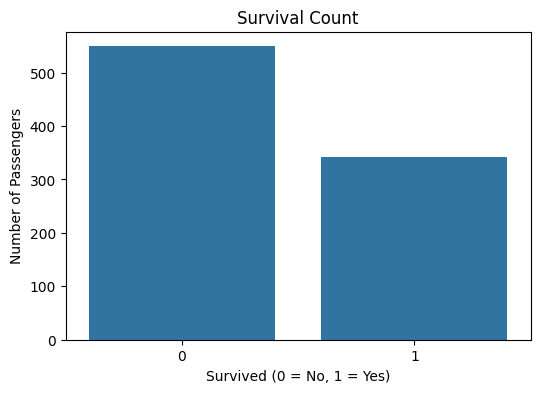

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(
    data=titanic_clean,
    x="survived"
)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

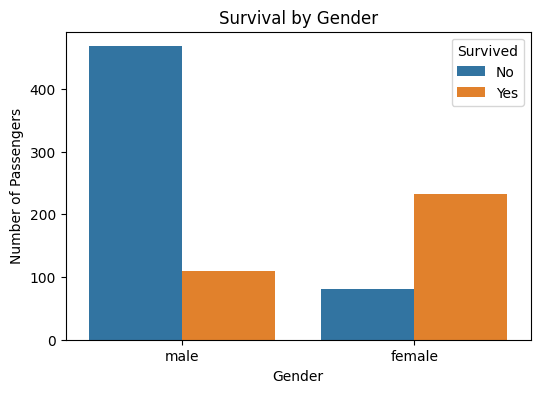

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=titanic_clean,
    x="sex",
    hue="survived"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

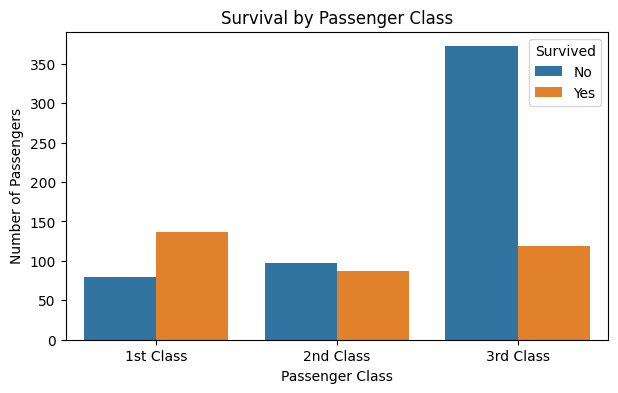

In [10]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=titanic_clean,
    x="pclass",
    hue="survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.xticks([0, 1, 2], ["1st Class", "2nd Class", "3rd Class"])
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

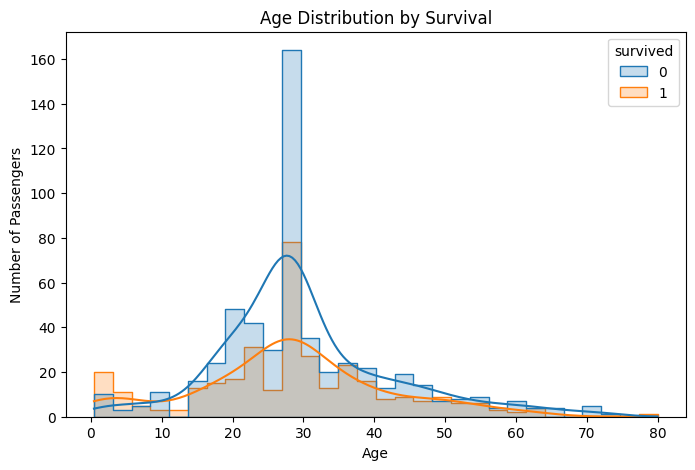

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=titanic_clean,
    x="age",
    hue="survived",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

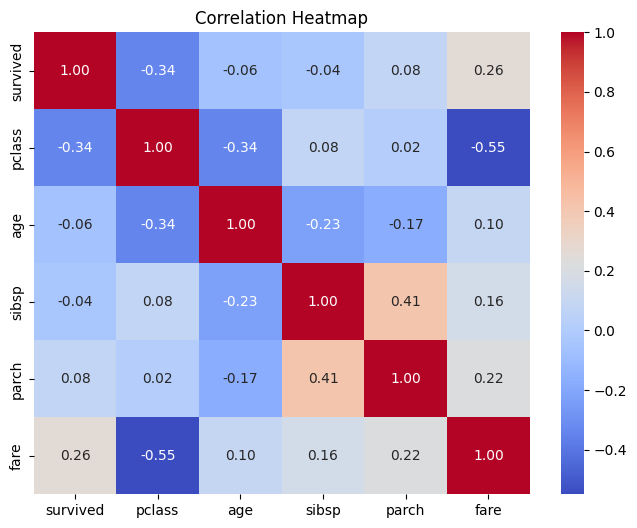

In [12]:
plt.figure(figsize=(8, 6))

correlation = titanic_clean[
    ["survived", "pclass", "age", "sibsp", "parch", "fare"]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [13]:
gender_survival_rate = titanic_clean.groupby("sex")["survived"].mean() * 100

gender_survival_rate

sex
female    74.203822
male      18.890815
Name: survived, dtype: float64

In [14]:
class_survival_rate = titanic_clean.groupby("pclass")["survived"].mean() * 100

class_survival_rate

pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64

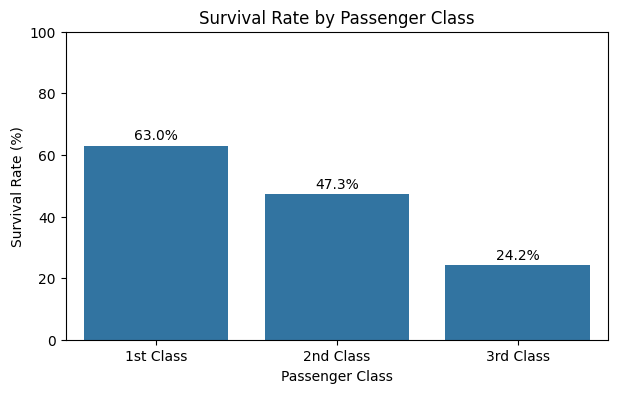

In [15]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=class_survival_rate.index,
    y=class_survival_rate.values
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.xticks([0, 1, 2], ["1st Class", "2nd Class", "3rd Class"])
plt.ylim(0, 100)

for i, rate in enumerate(class_survival_rate.values):
    plt.text(i, rate + 2, f"{rate:.1f}%", ha="center")

plt.show()

In [16]:
gender_class_survival = titanic_clean.pivot_table(
    values="survived",
    index="pclass",
    columns="sex",
    aggfunc="mean"
) * 100

gender_class_survival

sex,female,male
pclass,,
1,96.808511,36.885246
2,92.105263,15.740741
3,50.000000,13.544669


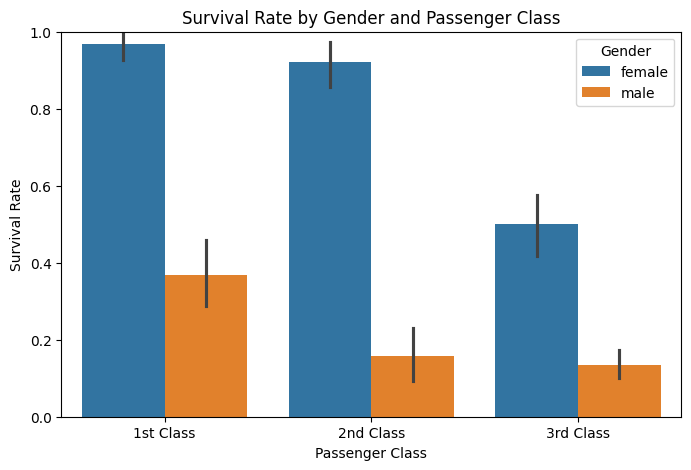

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=titanic_clean,
    x="pclass",
    y="survived",
    hue="sex",
    estimator="mean"
)

plt.title("Survival Rate by Gender and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.xticks([0, 1, 2], ["1st Class", "2nd Class", "3rd Class"])
plt.ylim(0, 1)

plt.legend(title="Gender")
plt.show()


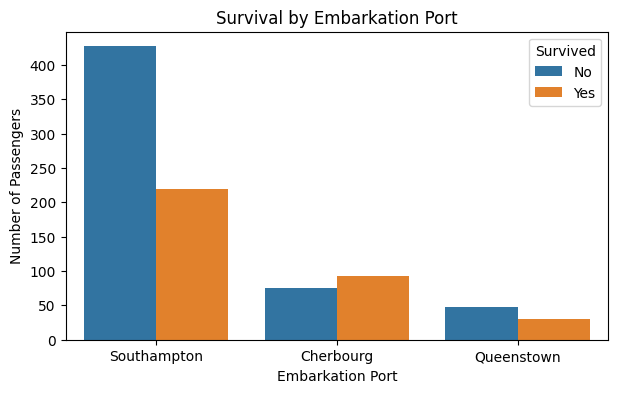

In [18]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=titanic_clean,
    x="embark_town",
    hue="survived"
)

plt.title("Survival by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

In [19]:
embark_survival_rate = (
    titanic_clean.groupby("embark_town")["survived"].mean() * 100
)

embark_survival_rate

embark_town
Cherbourg      55.357143
Queenstown     38.961039
Southampton    33.900929
Name: survived, dtype: float64

In [20]:
titanic_clean.to_csv("titanic_clean.csv", index=False)

print("Cleaned Titanic dataset saved successfully!")

Cleaned Titanic dataset saved successfully!


In [21]:
import os

print(os.path.exists("titanic_clean.csv"))

True
